# Importing libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2  # for distance calc

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


# Data Cleaning

In [2]:
# ── Step 1: Fix string columns ──────────────────────────────
df['Time_taken(min)'] = df['Time_taken(min)'].str.extract(r'(\d+)').astype(float)
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False).str.strip()

# ── Step 2: Convert to numeric (coerce turns bad strings → NaN) ─
df['Delivery_person_Age']     = pd.to_numeric(df['Delivery_person_Age'].str.strip(), errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'].str.strip(), errors='coerce')
df['multiple_deliveries']     = pd.to_numeric(df['multiple_deliveries'].str.strip(), errors='coerce')

# ── Step 3: Time features ────────────────────────────────────
df['Time_Orderd']       = pd.to_datetime(df['Time_Orderd'].str.strip(), format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'].str.strip(), format='%H:%M:%S', errors='coerce')
df['prep_time_min'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60
df['prep_time_min'] = df['prep_time_min'].apply(lambda x: x + 1440 if pd.notna(x) and x < 0 else x)
df['order_hour']  = df['Time_Orderd'].dt.hour
df['Order_Date']  = pd.to_datetime(df['Order_Date'].str.strip(), format='%d-%m-%Y', errors='coerce')
df['day_of_week'] = df['Order_Date'].dt.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [3]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [4]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


# Distance between restaurant and customer distance calculated by haaversine forlumae:


In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

df['distance_km'] = df.apply(
    lambda row: haversine(row['Restaurant_latitude'], row['Restaurant_longitude'],
                          row['Delivery_location_latitude'], row['Delivery_location_longitude']), axis=1)

# Exploratory Data Analysis understanding data on graphs in visuals

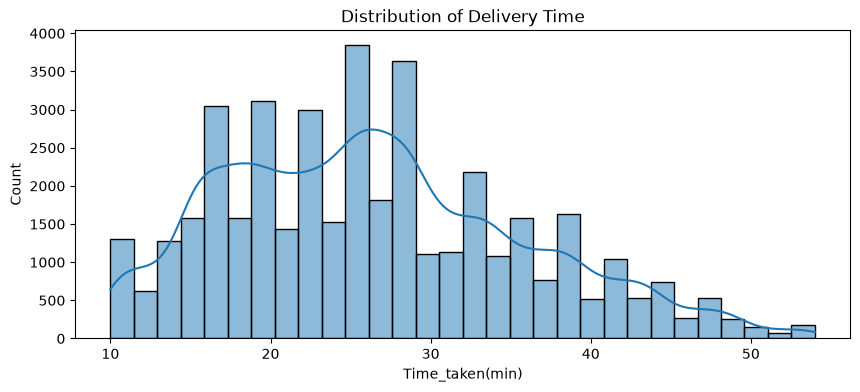

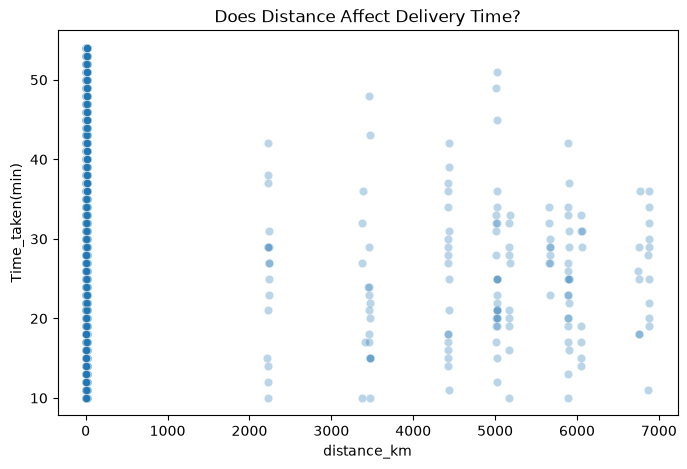

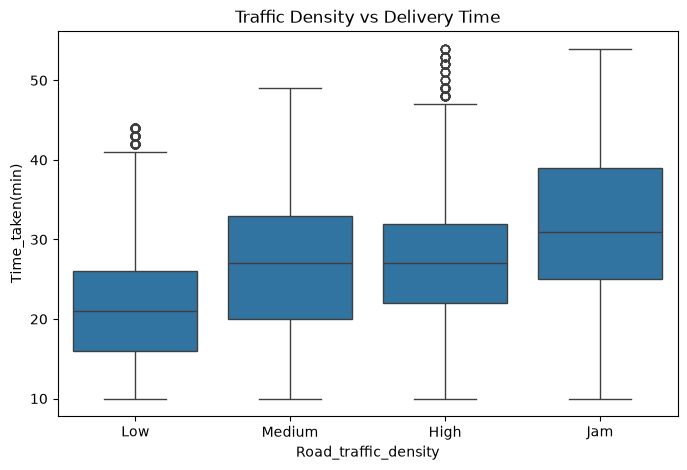

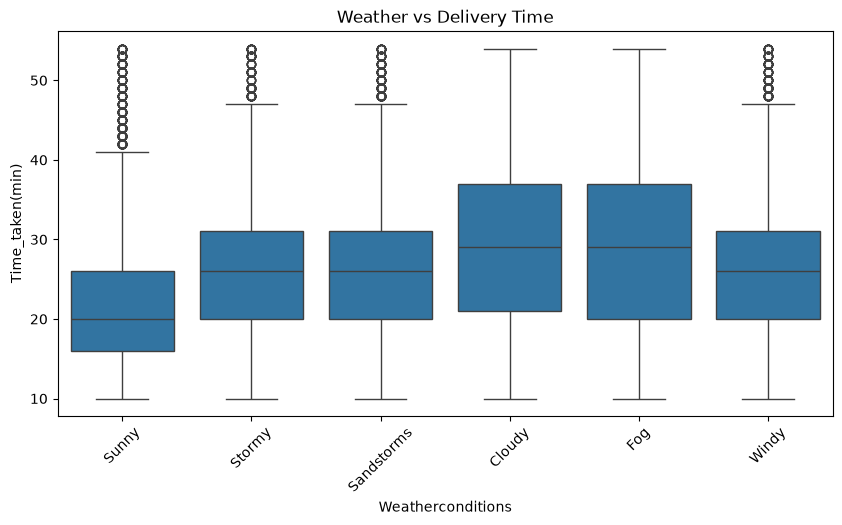

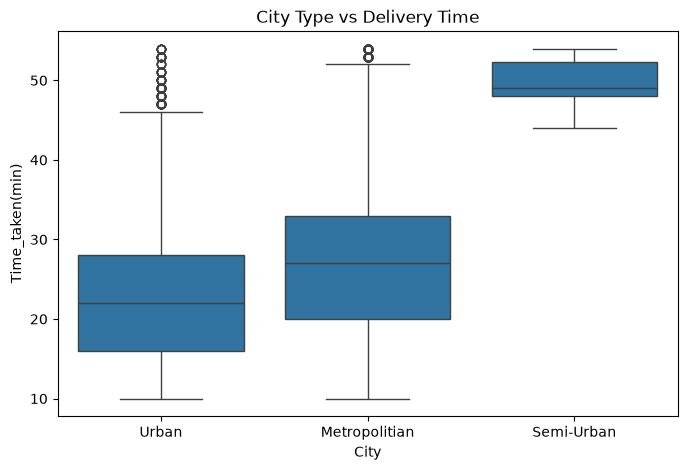

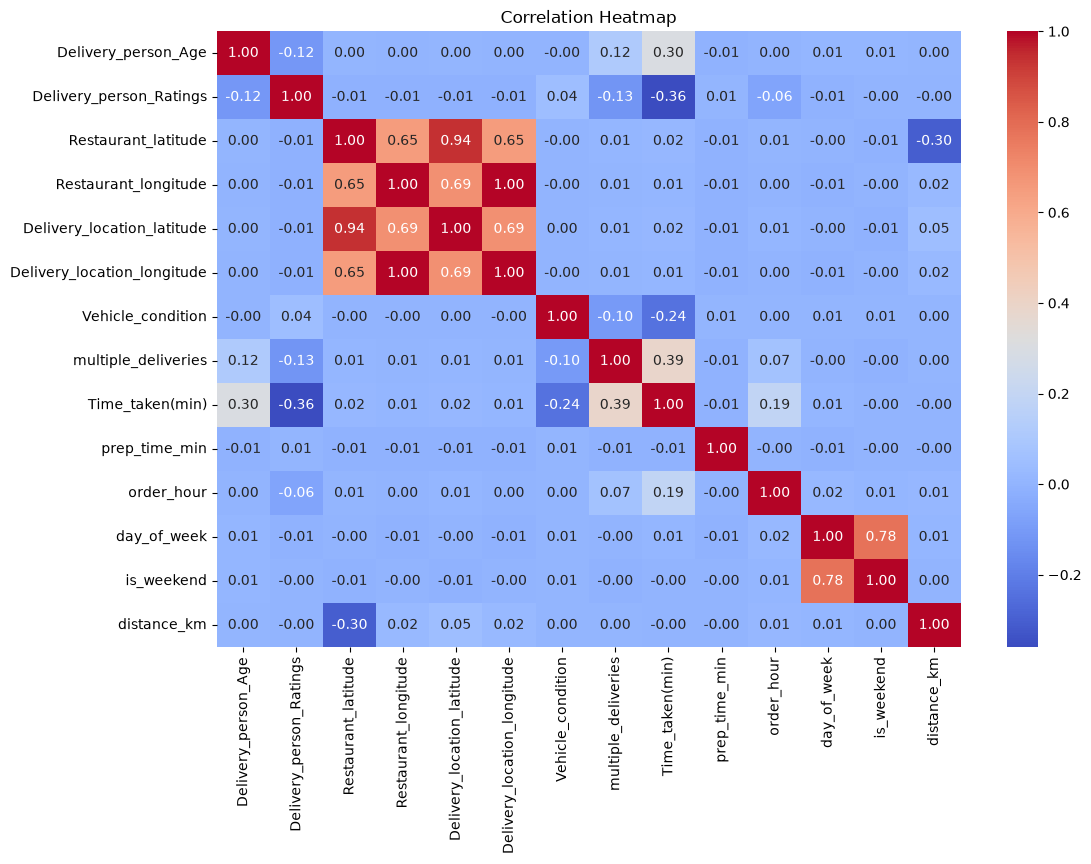

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Strip spaces from these columns first ──────────────────
df['Road_traffic_density'] = df['Road_traffic_density'].str.strip()
df['City'] = df['City'].str.strip()

# Then re-drop the 'NaN' string rows
df = df[df['Road_traffic_density'] != 'NaN']
df = df[df['City'] != 'NaN']
df = df[df['Weatherconditions'] != 'NaN']

# ── 1. Distribution of delivery time ──────────────────────
plt.figure(figsize=(10, 4))
sns.histplot(df['Time_taken(min)'], bins=30, kde=True)
plt.title('Distribution of Delivery Time')
plt.show()

# ── 2. Distance vs Time ────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='distance_km', y='Time_taken(min)', alpha=0.3)
plt.title('Does Distance Affect Delivery Time?')
plt.show()

# ── 3. Traffic vs Time — now order matches actual values ──
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Road_traffic_density', y='Time_taken(min)',
            order=['Low', 'Medium', 'High', 'Jam'])   # ✅ no spaces now
plt.title('Traffic Density vs Delivery Time')
plt.show()

# ── 4. Weather vs Time ─────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Weatherconditions', y='Time_taken(min)')
plt.xticks(rotation=45)
plt.title('Weather vs Delivery Time')
plt.show()

# ── 5. City type vs Time ───────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='City', y='Time_taken(min)')
plt.title('City Type vs Delivery Time')
plt.show()

# ── 6. Correlation Heatmap ─────────────────────────────────
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# performing label encoding

In [7]:
# Columns to encode
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
            'Type_of_vehicle', 'Festival', 'City']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].str.strip())

In [8]:
drop_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked']
X = df.drop(columns=drop_cols + ['Time_taken(min)'])
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training tha data on 4 different models to get the best model

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }
    print(f"{name}: MAE={results[name]['MAE']:.2f}, R²={results[name]['R2']:.4f}")

Linear Regression: MAE=5.31, R²=0.5123
Decision Tree: MAE=3.97, R²=0.6979
Random Forest: MAE=3.07, R²=0.8375
Gradient Boosting: MAE=3.40, R²=0.7982


Text(0.5, 1.0, 'Feature Importance — Random Forest')

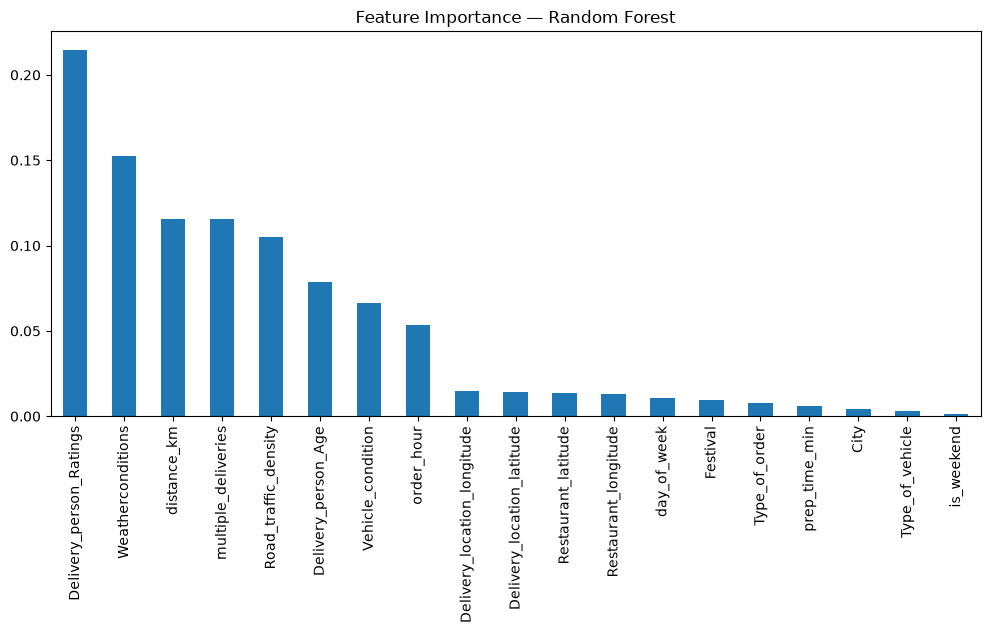

In [10]:
rf_model = models['Random Forest']
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title('Feature Importance — Random Forest')

# performing Hyperparameter tunning to get the best parameter for the model

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
search = RandomizedSearchCV(rf, param_grid, n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best R²:", search.best_score_)

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best R²: 0.8394260350719209


In [12]:
best_model = search.best_estimator_
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV R² scores: [0.84161591 0.84040953 0.84238355 0.837496   0.84170789]
Mean R²: 0.8407 ± 0.0017


Text(0.5, 1.0, 'Residual Distribution')

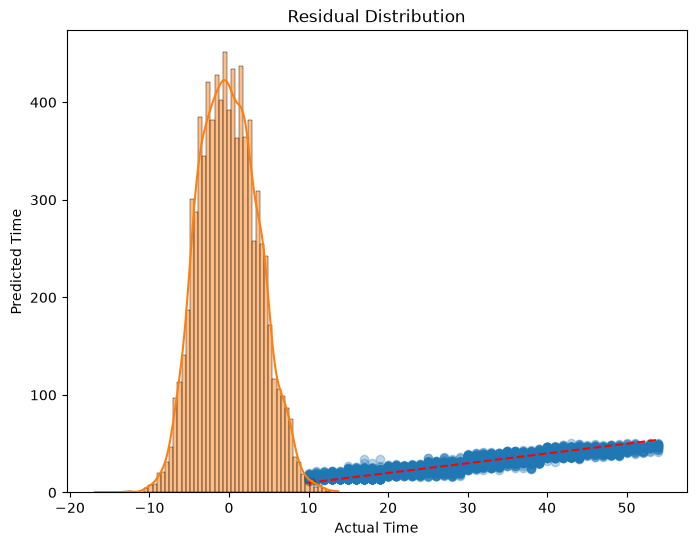

In [13]:
final_preds = best_model.predict(X_test)

# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Time')
plt.ylabel('Predicted Time')
plt.title('Actual vs Predicted Delivery Time')

# Residuals
residuals = y_test - final_preds
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')

# This one is for updating Readme file With metrics

In [15]:
import re

# Build rows from your results dict (already populated above)
with open("README.md", "r", encoding="utf-8") as f:
    content = f.read()

for model_name, metrics in results.items():
    mae  = metrics['MAE']
    rmse = metrics['RMSE']
    r2   = metrics['R2']

    # Match the placeholder row and replace with real values
    pattern     = rf"(\|\s*{re.escape(model_name)}\s*\|)\s*—\s*\|\s*—\s*\|\s*—\s*\|"
    replacement = rf"\1 {mae:.2f} | {rmse:.2f} | {r2:.4f} |"
    content     = re.sub(pattern, replacement, content)

with open("README.md", "w", encoding="utf-8") as f:
    f.write(content)

print("✅ README updated!")
for m, v in results.items():
    print(f"  {m}: MAE={v['MAE']:.2f}, RMSE={v['RMSE']:.2f}, R²={v['R2']:.4f}")

✅ README updated!
  Linear Regression: MAE=5.31, RMSE=6.60, R²=0.5123
  Decision Tree: MAE=3.97, RMSE=5.20, R²=0.6979
  Random Forest: MAE=3.07, RMSE=3.81, R²=0.8375
  Gradient Boosting: MAE=3.40, RMSE=4.25, R²=0.7982
